# Calibrate car edge weights against observed trip times

Iteratively calibrates the per-edge duration formula for cars against
Google-Maps-derived point-to-point travel times. All inputs come from
`prepare/`: the consolidated car graph (`prepare/1_download` for
topology + intersection / signal flags + OSM speeds) and per-edge
`density_norm` (`prepare/5_density`).

**Calibration model** (see `aperta.calibration` module docstring):

```
trip_time = α · baseline_time
          + Σ_m coef_m · (baseline_time · m_avg_along_path)
          + Σ_a coef_a · (a_sum_along_path)
          + Σ_e coef_e · (e_at_origin + e_at_destination)
          + constant
```

`baseline_time` is per-edge `length / speed_kph` (with `speed_kph`
from OSM `maxspeed` + per-highway fallback, set in `prepare/1_download`).
This stays unchanged across iterations — the calibration learns the
multiplicative correction `α` and the per-feature coefficients.

**Ground truth**: Google-Maps `car_pessimistic.csv` (~50 k legs),
columns `orig_x, orig_y, dest_x, dest_y, time_measured, dist_measured,
dist_line`. Origin coordinates are derived from the protected MTMC
survey, so this specific data file isn't public — the workflow itself
is the reusable part. Replacement data with the same schema would slot
in directly.

In [3]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from shapely.geometry import Point

from aperta import calibration, geo_processing, network_processing

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

PREPARED_DIR = Path('data/prepared')
GROUND_TRUTH_PATH = Path('data/ground_truth/travel_times_car_peak.csv')
CRS_METRIC = 'EPSG:2056'

## 1. Load graph + cells + ground truth

In [4]:
car_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'car_graph.graphml')
print(f"Car graph: {car_graph.number_of_nodes():,} nodes / "
      f"{car_graph.number_of_edges():,} edges")

cells = gpd.read_file(PREPARED_DIR / 'cells.gpkg').set_index('cell_id')
cells['pop_plus_emp'] = cells['population'] + cells['employment_total']
print(f"Cells: {len(cells):,}")

legs = pd.read_csv(GROUND_TRUTH_PATH)
print(f"Ground-truth legs: {len(legs):,} "
      f"(median time {legs['time_measured'].median():.0f} s, "
      f"median dist {legs['dist_measured'].median():.0f} m)")

Car graph: 33,860 nodes / 90,839 edges
Cells: 142,209
Ground-truth legs: 49,773 (median time 671 s, median dist 5685 m)


## 2. Per-edge features (from prep)

All features used by the calibration formula below are already on the
graph from the prep notebooks:

- `speed_kph` per edge (from `prepare/1_download`)
- `density_norm`, `is_degree_4`, `is_traffic_signal` per edge (from
  `prepare/5_density`)

These attrs are cast back to floats on graphml load via
`network_processing.CONSOLIDATED_EDGE_DTYPES`, which
`load_consolidated_graphml` applies. Just a diagnostic.

In [5]:
speeds = np.array([float(d['speed_kph'])
                   for _, _, d in car_graph.edges(data=True)])
print(f"Baseline car edge speeds: median {np.median(speeds):.0f} km/h, "
      f"range {speeds.min():.0f}–{speeds.max():.0f} km/h.")

Baseline car edge speeds: median 30 km/h, range 10–120 km/h.


## 3. Calibrate

Three feature classes enter the OLS fit:

- **multiplier**: scales baseline duration. `coef · baseline ·
  feature_value`. Density would belong here — left empty in this
  showcase to keep the model interpretable.
- **additive_route**: adds seconds per occurrence, summed along the
  routed path. Intersection counts, traffic signals.
- **additive_endpoint**: adds seconds based on the value of a node
  attribute at origin and destination. Snap distance (cell centroid
  → nearest network node).

Initial coefficients chosen close to typical car off-peak values so
the first iteration starts near a plausible regime. `n_iterations=3`
is usually enough to converge.

In [10]:
result = calibration.calibrate_edge_weights(
    car_graph, legs,
    baseline_speed_attr='speed_kph',
    multiplier_features={
        'density_norm':      0.2,    # Higher density = lower speeds
    },
    additive_route_features={
        # is_degree_3 dropped — multicollinear with density.
        'is_degree_4':       2.6,    # secs per 4-way intersection
        'is_traffic_signal': 4.4,    # secs per signalised intersection
    },
    additive_endpoint_features={
        # Density at orig/dest dropped — overfitting risk on small n.
        'snap_dist':         0.2,    # secs per metre of first-mile distance
    },
    constant=True,
    n_iterations=3,
    min_trip_distance=500.0,
    max_dist_to_line_ratio=5.0,
)

## 4. Results

In [11]:
print(f"\nR² = {result.r_squared:.4f}   "
      f"RMSE = {result.rmse:.1f} s   "
      f"n = {result.n_used:,} trips")
print("\nRMSE by distance band:")
print(result.rmse_by_distance.round(1).to_string())
print("\nCoefficient table:")
print(result.coefficients.to_string())
print("\nIteration log:")
print(result.iter_log.round(4).to_string())


R² = 0.9594   RMSE = 143.6 s   n = 7,448 trips

RMSE by distance band:
< 10 km     112.4
10-25 km    193.9
>= 25 km    296.6

Coefficient table:
                                 kind     coef       p  mean_effect
const                           const  76.2528  0.0000      76.2528
baseline_time                baseline   1.1121  0.0000     676.5751
density_norm__mult         multiplier   0.2962  0.0000      70.0600
is_degree_4            additive_route   3.6627  0.0000      23.1453
is_traffic_signal      additive_route   6.6856  0.0009       2.9353
snap_dist_orig      additive_endpoint  -0.0058  0.8571      -0.4374
snap_dist_dest      additive_endpoint  -0.0064  0.8445      -0.4764

Iteration log:
           r_squared      rmse  n_used   alpha
iteration                                     
1             0.9594  143.5705    7448  1.1101
2             0.9595  143.3577    7448  0.9988
3             0.9594  143.6297    7448  1.1121


## 5. Observed vs predicted

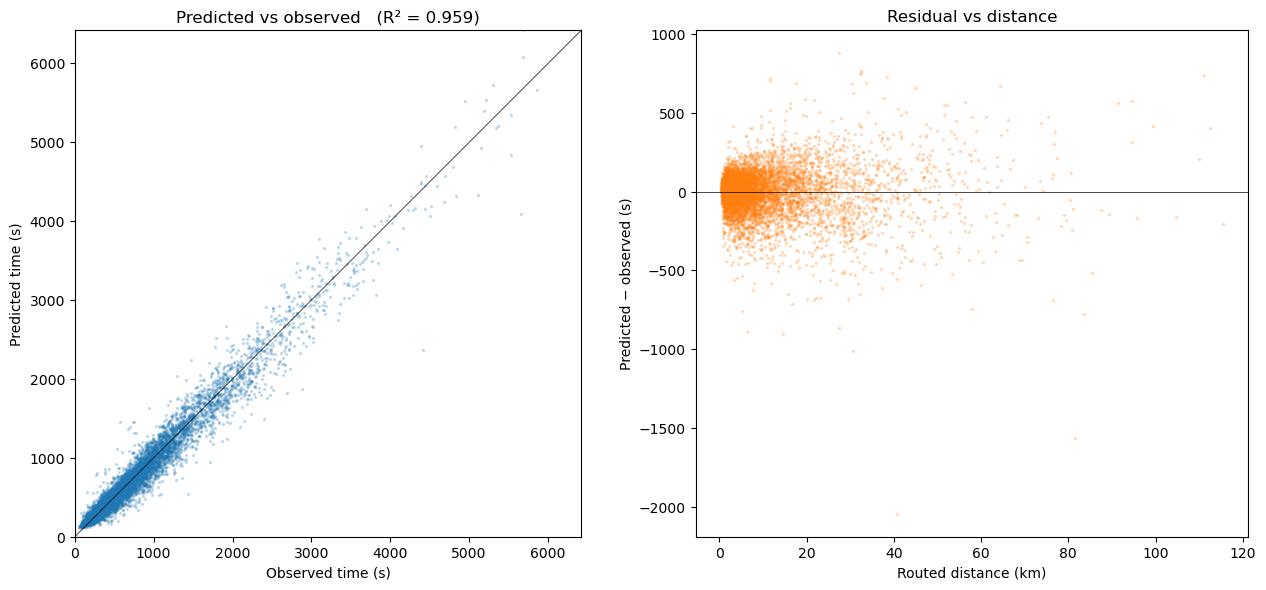

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Scatter
ax = axes[0]
ax.scatter(result.observed_times, result.predicted_times,
           s=2, alpha=0.2, color='tab:blue')
lim = max(result.observed_times.max(), result.predicted_times.max())
ax.plot([0, lim], [0, lim], color='black', linewidth=0.5)
ax.set_xlabel('Observed time (s)')
ax.set_ylabel('Predicted time (s)')
ax.set_title(f'Predicted vs observed   (R² = {result.r_squared:.3f})')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect('equal')

# Residual vs distance
ax = axes[1]
residuals = result.predicted_times - result.observed_times
ax.scatter(result.routed_distances / 1000, residuals,
           s=2, alpha=0.2, color='tab:orange')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Routed distance (km)')
ax.set_ylabel('Predicted − observed (s)')
ax.set_title('Residual vs distance')

plt.tight_layout()
plt.show()

## 6. Export the calibrated graph

`calibrate_edge_weights` writes the fitted per-edge duration to
`car_graph[u][v][k][result.edge_duration_attr]` (default
`'duration_calibrated'`) on every edge. The graph is now self-contained
— anything that can read GraphML can pick up the calibrated weights.

In [13]:
ox.save_graphml(car_graph, PREPARED_DIR / 'car_graph_calibrated.graphml')

# Companion GeoPackage of edges — opens directly in QGIS / ArcGIS for
# inspection, and serves as a portable cross-tool exchange format.
edges_gdf = ox.graph_to_gdfs(car_graph, nodes=False)
edges_gdf[['length', 'speed_kph', result.edge_duration_attr, 'geometry']].to_file(
    PREPARED_DIR / 'car_edges_calibrated.gpkg', driver='GPKG',
)
print(f"Wrote calibrated graph + edge layer to {PREPARED_DIR}/.")

Wrote calibrated graph + edge layer to data/prepared/.


### Consuming the calibrated weights from Pandana

[Pandana](https://github.com/UDST/pandana) is a fast C++ routing engine
widely used for cumulative-opportunity accessibility. Aperta and Pandana
are complementary: aperta produces calibrated, multi-modal,
behaviour-anchored edge weights; Pandana consumes them for
high-throughput single-mode shortest-path queries on a fixed network.

```python
import osmnx as ox
import pandana
import pandas as pd

g = ox.load_graphml('data/prepared/car_graph_calibrated.graphml')
nodes = ox.graph_to_gdfs(g, edges=False)
edges = ox.graph_to_gdfs(g, nodes=False).reset_index()

net = pandana.Network(
    node_x=nodes['x'], node_y=nodes['y'],
    edge_from=edges['u'], edge_to=edges['v'],
    edge_weights=edges[['duration_calibrated']],
)
net.set(pd.Series(supermarket_node_ids, index=supermarket_node_ids),
        name='supermarkets')
n_within_15min = net.aggregate(
    distance=15 * 60, type='count', name='supermarkets',
)
```

The same `.graphml` loads into NetworkX, igraph, r5py, and any custom
Dijkstra implementation. Calibration is a one-time step whose product
is a standard graph file — downstream tooling is the caller's choice.

## What this notebook does NOT do

This is a self-contained demo of one library capability — calibrating
per-edge durations against observed point-to-point travel times. To
keep it readable as a tutorial, it deliberately omits things that
matter for production:

- **No flows / traffic-flow features.** The library's
  `calibrate_edge_weights` accepts arbitrary multiplier features, so a
  `flow_estimate` AADT estimate (see `traffic_flows.ipynb`) can enter
  through a BPR-style `(V/C)²` transform to capture congestion. The
  production lumos pipeline does this. Showcase keeps the model
  interpretable.
- **No iterative refinement on stricter trip filters.** Production
  typically iterates filters (drop trip outliers, retain only trips
  within a polygon, etc.) — we use a single set here.
- **Export not consumed by `accessibility.ipynb`.** The calibrated
  GraphML written in §6 isn't picked up by the other notebooks —
  `accessibility.ipynb` uses published-paper coefficients instead.
  Each showcase notebook stands alone; they aren't wired into a pipeline.

For an example of these pieces wired into a full production stack
with `aperta_lab` scaffolding (scenario configs, typed I/O,
dependency tracking), see
[`aperta-lab/src/projects/lumos/calibration/`](https://github.com/mmiotti/aperta-lab/tree/main/src/projects/lumos/calibration).